In [53]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions

In [50]:
df = pd.read_csv("Datasets/placement.csv")

In [4]:
df.head(5)

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [8]:
df = df.iloc[:,1:]
# it removes number 0 column 

In [9]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


# EDA

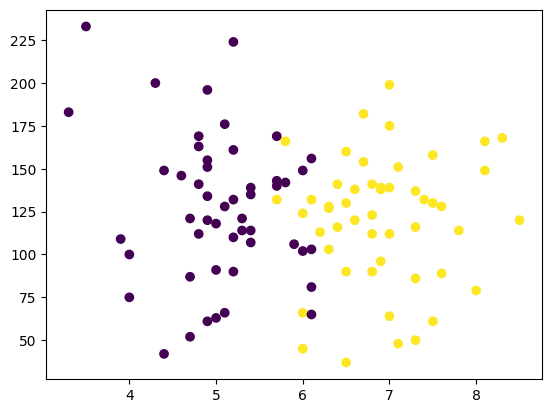

In [11]:
plt.scatter(df['cgpa'],df['iq'], c=df['placement'])

# Extract input and ouptut col

In [12]:
x= df.iloc[:,0:2]
y=df.iloc[:,-1]

In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

# Train, Test data splitting

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.1)

In [23]:
x_train

,cgpa,iq
68,4.0,75.0
8,6.1,156.0
78,6.1,81.0
42,7.6,89.0
70,6.3,127.0
...,...,...
29,7.0,112.0
81,5.4,107.0
49,5.4,135.0
86,5.1,128.0


In [24]:
y_test

63    1
4     0
79    1
34    0
66    1
71    1
27    1
91    1
96    0
5     1
Name: placement, dtype: int64

# Scaling

In [29]:
scaler = StandardScaler()   
x_train = scaler.fit_transform(x_train)

In [30]:
x_train

array([[-1.70445069, -1.26173816],
       [ 0.10838657,  0.78911383],
       [ 0.10838657, -1.1098232 ],
       [ 1.40327032, -0.90726992],
       [ 0.28103773,  0.05485818],
       [-1.01384602,  1.11826292],
       [-0.23691577,  0.45996475],
       [ 0.71266565, -0.04641846],
       [ 0.88531682,  1.27017788],
       [ 0.02206098,  0.61187971],
       [-1.79077628, -0.40088671],
       [ 1.14429357, -0.22365258],
       [-1.44547394,  1.90315689],
       [ 0.36736332,  0.40932643],
       [ 0.88531682, -1.54024893],
       [-0.66854369,  0.18145398],
       [ 2.18020058, -0.12237594],
       [-2.13607861,  2.73868919],
       [-0.15059019,  1.04230544],
       [ 0.9716424 ,  0.66251803],
       [ 0.71266565,  0.40932643],
       [-0.92752044,  0.66251803],
       [-1.10017161, -0.09705678],
       [-0.75486927, -1.48961061],
       [-0.66854369,  2.51081674],
       [-1.10017161, -0.95790824],
       [-0.92752044, -1.61620641],
       [-2.30872978,  1.47273117],
       [-0.5822181 ,

In [33]:
x_test = scaler.transform(x_test)

In [34]:
x_test

array([[ 0.28103773,  0.08017734],
       [-0.15059019,  0.43464559],
       [ 0.4536889 , -0.88195076],
       [-1.01384602,  0.96634796],
       [ 0.79899124, -0.73003579],
       [ 0.10838657,  0.18145398],
       [ 0.02206098, -0.0210993 ],
       [ 1.31694474,  0.83975215],
       [-1.35914836, -2.09727046],
       [ 0.9716424 , -1.94535549]])

# Model Training

In [37]:
clf = LogisticRegression()

In [38]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

# Model Evaluation

In [41]:
y_pred=clf.predict(x_test)

In [42]:
y_test

63    1
4     0
79    1
34    0
66    1
71    1
27    1
91    1
96    0
5     1
Name: placement, dtype: int64

In [44]:
accuracy_score(y_test,y_pred)

0.9

# Visualizing ML pattern 

<Axes: >

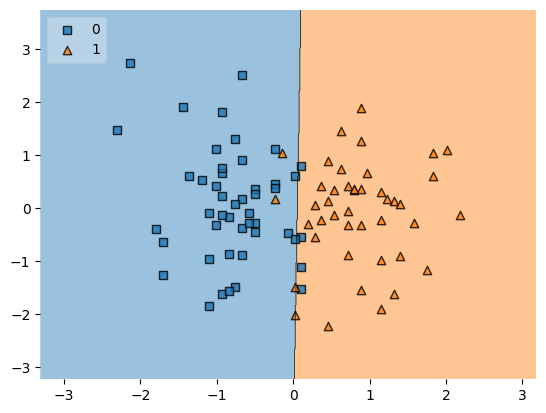

In [55]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [58]:
import pickle  #converting obj into file as python is all about object

In [57]:
pickle.dump(clf,open('model.pkl','wb'))